In [16]:
import pandas as pd
import numpy as np

df = pd.read_csv("../../Project_banking-fraud-DATA/1_FraudShield_Banking_Data (1).csv", header=0, index_col=0)

In [17]:

##Normalizing column headers

df.columns = (
    df.columns
    .str.lower()
    .str.replace('(', '_', regex=False)   # replace ( with _
    .str.replace('/', '_', regex=False)   # replace ( with _
    .str.replace(')', '', regex=False)    # remove )
    .str.replace(r'[^\w\s]', '', regex=True)  # remove other special chars
    .str.replace(' ', '_')                # spaces → underscore
    .str.replace('__', '_')
)
df.columns

Index(['customer_id', 'transaction_amount_in_million', 'transaction_time',
       'transaction_date', 'transaction_type', 'merchant_id',
       'merchant_category', 'transaction_location', 'customer_home_location',
       'distance_from_home', 'device_id', 'ip_address', 'card_type',
       'account_balance_in_million', 'daily_transaction_count',
       'weekly_transaction_count', 'avg_transaction_amount_in_million',
       'max_transaction_last_24h_in_million', 'is_international_transaction',
       'is_new_merchant', 'failed_transaction_count',
       'unusual_time_transaction', 'previous_fraud_count', 'fraud_label'],
      dtype='object')

In [18]:
#Explore all data
print("\n", "Head:","\n", df.head(5))
print("\n", "Tail:","\n", df.tail(5))
print("\n", "Null Values:","\n", df.isna().sum())
print("\n", "Info:","\n", df.info())
print("\n", "Info Memory Usage:","\n", df.info(memory_usage="deep"))
print("\n", "Describe:","\n", df.describe())
print("\n", "Describe All:","\n", df.describe(include="all"))
print("\n", "Shape:","\n", df.shape)
print("\n", "DTypes:","\n", df.dtypes)
print("\n", "Columns:","\n", df.columns)
print("\n", "Index:","\n", df.index)
print("\n", "Values:","\n", df.values)
print("\n", "Empty:","\n", df.empty)
print("\n", "NDim:","\n", df.ndim)
print("\n", "Size:","\n", df.size)
#print("\n", "Memory True:","\n", df.memory_usage(deep=True))




 Head: 
                 customer_id  transaction_amount_in_million transaction_time  \
Transaction_ID                                                                
431438.0            24239.0                            6.0            10:54   
902451.0            77250.0                            9.0            19:23   
223410.0            34294.0                            3.0            10:20   
145626.0            92041.0                            1.0            14:11   
414637.0            71578.0                            1.0            04:12   

               transaction_date transaction_type  merchant_id  \
Transaction_ID                                                  
431438.0             2025-03-08              POS      97028.0   
902451.0             2025-01-17              ATM      27515.0   
223410.0             2025-04-30              POS      13810.0   
145626.0             2025-02-21           Online      10501.0   
414637.0             2025-04-11           Onli

In [19]:

#split cols into different columns 
numerical_cols = df.select_dtypes(include=np.number)
print("numerical clomumns", numerical_cols)

#be careful because some categorical values my sip into numerical_cols (numbers that represent category)
categorical_cols = df.select_dtypes(exclude=np.number)
print("categorical clomumns",categorical_cols)

numerical clomumns                 customer_id  transaction_amount_in_million  merchant_id  \
Transaction_ID                                                            
431438.0            24239.0                            6.0      97028.0   
902451.0            77250.0                            9.0      27515.0   
223410.0            34294.0                            3.0      13810.0   
145626.0            92041.0                            1.0      10501.0   
414637.0            71578.0                            1.0      53569.0   
...                     ...                            ...          ...   
805949.0            87401.0                            4.0      13857.0   
168493.0            65425.0                            4.0      25552.0   
996197.0            14318.0                            9.0      41771.0   
444042.0            55757.0                            1.0      72485.0   
121538.0            57274.0                            7.0      69446.0   

     

In [20]:
df.head(100)

,customer_id,transaction_amount_in_million,transaction_time,transaction_date,transaction_type,merchant_id,merchant_category,transaction_location,customer_home_location,distance_from_home,...,daily_transaction_count,weekly_transaction_count,avg_transaction_amount_in_million,max_transaction_last_24h_in_million,is_international_transaction,is_new_merchant,failed_transaction_count,unusual_time_transaction,previous_fraud_count,fraud_label
Transaction_ID,,,,,,,,,,,,,,,,,,,,,
431438.0,24239.0,6.0,10:54,2025-03-08,POS,97028.0,ATM,Singapore,Lahore,466.0,...,4.0,17.0,2.0,4.0,Yes,Yes,0.0,No,1.0,Normal
902451.0,77250.0,9.0,19:23,2025-01-17,ATM,27515.0,ATM,Singapore,Lahore,215.0,...,4.0,9.0,5.0,8.0,Yes,Yes,1.0,No,1.0,Normal
223410.0,34294.0,3.0,10:20,2025-04-30,POS,13810.0,Electronics,Faisalabad,Faisalabad,216.0,...,5.0,18.0,5.0,8.0,Yes,No,0.0,Yes,1.0,Normal
145626.0,92041.0,1.0,14:11,2025-02-21,Online,10501.0,Grocery,London,Karachi,408.0,...,6.0,18.0,5.0,1.0,No,Yes,2.0,Yes,1.0,Normal
414637.0,71578.0,1.0,04:12,2025-04-11,Online,53569.0,Electronics,Singapore,Islamabad,209.0,...,3.0,18.0,4.0,3.0,No,Yes,1.0,No,1.0,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
603311.0,74137.0,2.0,09:25,2025-04-27,Online,32876.0,Restaurant,Singapore,Faisalabad,596.0,...,1.0,10.0,4.0,2.0,No,Yes,1.0,No,1.0,Normal
478545.0,34516.0,4.0,22:43,2025-04-27,POS,96893.0,Electronics,Lahore,Multan,5.0,...,3.0,23.0,5.0,1.0,No,Yes,2.0,No,1.0,Fraud
896253.0,57088.0,3.0,16:50,2025-02-17,ATM,92750.0,Electronics,Dubai,Lahore,218.0,...,2.0,5.0,1.0,8.0,Yes,Yes,2.0,No,0.0,Normal


In [21]:
#Duplicates to drop
#'customer_id', 'transaction_amount_in_million', 'transaction_time', 'transaction_date', 'transaction_type', 'merchant_id', 'merchant_category', 'transaction_location', 'customer_home_location', 'distance_from_home', 'device_id', 'ip_address', 'card_type', 'account_balance_in_million', 'daily_transaction_count', 'weekly_transaction_count', 'avg_transaction_amount_in_million', 'max_transaction_last_24h_in_million', 'is_international_transaction', 'is_new_merchant', 'failed_transaction_count', 'unusual_time_transaction', 'previous_fraud_count', 'fraud_label'

cols = [
    "customer_id",
    "transaction_amount_in_million",
    "transaction_time",
    "transaction_date",
    "transaction_type",
    "merchant_id",
    "merchant_category",
    "transaction_location",
    "customer_home_location",
    "distance_from_home",
    "device_id",
    "ip_address",
    "card_type",
    "account_balance_in_million",
    "daily_transaction_count",
    "weekly_transaction_count",
    "avg_transaction_amount_in_million",
    "max_transaction_last_24h_in_million",
    "is_international_transaction",
    "is_new_merchant",
    "failed_transaction_count",
    "unusual_time_transaction",
    "previous_fraud_count",
    "fraud_label",
]

duplicate_report = {}

for col in cols:
    vc = df[col].value_counts(dropna=False)
    dupes = vc[vc > 1]
    duplicate_report[col] = dupes.reset_index()
    duplicate_report[col].columns = [col, "count"]
duplicate_report

{'customer_id':       customer_id  count
 0             NaN     10
 1         88220.0      6
 2         10985.0      6
 3         43223.0      6
 4         15303.0      6
 ...           ...    ...
 9628      12126.0      2
 9629      90538.0      2
 9630      60470.0      2
 9631      30571.0      2
 9632      93803.0      2
 
 [9633 rows x 2 columns],
 'transaction_amount_in_million':    transaction_amount_in_million  count
 0                            3.0   5616
 1                            9.0   5602
 2                            2.0   5585
 3                            7.0   5571
 4                            4.0   5558
 5                            6.0   5531
 6                            5.0   5528
 7                            1.0   5506
 8                            8.0   5494
 9                            NaN      9,
 'transaction_time':      transaction_time  count
 0               13:46     63
 1               15:34     55
 2               07:44     53
 3               16:

In [22]:
#Drop NA
df = df.dropna()
df

,customer_id,transaction_amount_in_million,transaction_time,transaction_date,transaction_type,merchant_id,merchant_category,transaction_location,customer_home_location,distance_from_home,...,daily_transaction_count,weekly_transaction_count,avg_transaction_amount_in_million,max_transaction_last_24h_in_million,is_international_transaction,is_new_merchant,failed_transaction_count,unusual_time_transaction,previous_fraud_count,fraud_label
Transaction_ID,,,,,,,,,,,,,,,,,,,,,
431438.0,24239.0,6.0,10:54,2025-03-08,POS,97028.0,ATM,Singapore,Lahore,466.0,...,4.0,17.0,2.0,4.0,Yes,Yes,0.0,No,1.0,Normal
902451.0,77250.0,9.0,19:23,2025-01-17,ATM,27515.0,ATM,Singapore,Lahore,215.0,...,4.0,9.0,5.0,8.0,Yes,Yes,1.0,No,1.0,Normal
223410.0,34294.0,3.0,10:20,2025-04-30,POS,13810.0,Electronics,Faisalabad,Faisalabad,216.0,...,5.0,18.0,5.0,8.0,Yes,No,0.0,Yes,1.0,Normal
145626.0,92041.0,1.0,14:11,2025-02-21,Online,10501.0,Grocery,London,Karachi,408.0,...,6.0,18.0,5.0,1.0,No,Yes,2.0,Yes,1.0,Normal
414637.0,71578.0,1.0,04:12,2025-04-11,Online,53569.0,Electronics,Singapore,Islamabad,209.0,...,3.0,18.0,4.0,3.0,No,Yes,1.0,No,1.0,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
805949.0,87401.0,4.0,18:04,2025-02-09,POS,13857.0,Clothing,Faisalabad,Islamabad,571.0,...,1.0,5.0,4.0,2.0,Yes,No,1.0,No,0.0,Fraud
168493.0,65425.0,4.0,21:30,2025-03-12,Online,25552.0,Electronics,Faisalabad,Multan,433.0,...,4.0,7.0,1.0,6.0,Yes,Yes,2.0,No,0.0,Normal
996197.0,14318.0,9.0,11:54,2025-03-04,Online,41771.0,Electronics,Singapore,Lahore,161.0,...,5.0,15.0,4.0,2.0,Yes,Yes,0.0,No,1.0,Fraud


In [23]:
#Drop Columns which will not be used for the analysis
df.drop(
[
    "transaction_amount_in_million",
    "device_id",
    "ip_address",
    "avg_transaction_amount_in_million",
    "max_transaction_last_24h_in_million",
    "account_balance_in_million",
], axis=1)


,customer_id,transaction_time,transaction_date,transaction_type,merchant_id,merchant_category,transaction_location,customer_home_location,distance_from_home,card_type,daily_transaction_count,weekly_transaction_count,is_international_transaction,is_new_merchant,failed_transaction_count,unusual_time_transaction,previous_fraud_count,fraud_label
Transaction_ID,,,,,,,,,,,,,,,,,,
431438.0,24239.0,10:54,2025-03-08,POS,97028.0,ATM,Singapore,Lahore,466.0,Credit,4.0,17.0,Yes,Yes,0.0,No,1.0,Normal
902451.0,77250.0,19:23,2025-01-17,ATM,27515.0,ATM,Singapore,Lahore,215.0,Credit,4.0,9.0,Yes,Yes,1.0,No,1.0,Normal
223410.0,34294.0,10:20,2025-04-30,POS,13810.0,Electronics,Faisalabad,Faisalabad,216.0,Debit,5.0,18.0,Yes,No,0.0,Yes,1.0,Normal
145626.0,92041.0,14:11,2025-02-21,Online,10501.0,Grocery,London,Karachi,408.0,Debit,6.0,18.0,No,Yes,2.0,Yes,1.0,Normal
414637.0,71578.0,04:12,2025-04-11,Online,53569.0,Electronics,Singapore,Islamabad,209.0,Debit,3.0,18.0,No,Yes,1.0,No,1.0,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
805949.0,87401.0,18:04,2025-02-09,POS,13857.0,Clothing,Faisalabad,Islamabad,571.0,Credit,1.0,5.0,Yes,No,1.0,No,0.0,Fraud
168493.0,65425.0,21:30,2025-03-12,Online,25552.0,Electronics,Faisalabad,Multan,433.0,Credit,4.0,7.0,Yes,Yes,2.0,No,0.0,Normal
996197.0,14318.0,11:54,2025-03-04,Online,41771.0,Electronics,Singapore,Lahore,161.0,Debit,5.0,15.0,Yes,Yes,0.0,No,1.0,Fraud


In [31]:
df

,customer_id,transaction_amount_in_million,transaction_time,transaction_date,transaction_type,merchant_id,merchant_category,transaction_location,customer_home_location,distance_from_home,...,daily_transaction_count,weekly_transaction_count,avg_transaction_amount_in_million,max_transaction_last_24h_in_million,is_international_transaction,is_new_merchant,failed_transaction_count,unusual_time_transaction,previous_fraud_count,fraud_label
Transaction_ID,,,,,,,,,,,,,,,,,,,,,
431438.0,24239.0,6.0,10:54,2025-03-08,POS,97028.0,ATM,Singapore,Lahore,466.0,...,4.0,17.0,2.0,4.0,Yes,Yes,0.0,No,1.0,Normal
902451.0,77250.0,9.0,19:23,2025-01-17,ATM,27515.0,ATM,Singapore,Lahore,215.0,...,4.0,9.0,5.0,8.0,Yes,Yes,1.0,No,1.0,Normal
223410.0,34294.0,3.0,10:20,2025-04-30,POS,13810.0,Electronics,Faisalabad,Faisalabad,216.0,...,5.0,18.0,5.0,8.0,Yes,No,0.0,Yes,1.0,Normal
145626.0,92041.0,1.0,14:11,2025-02-21,Online,10501.0,Grocery,London,Karachi,408.0,...,6.0,18.0,5.0,1.0,No,Yes,2.0,Yes,1.0,Normal
414637.0,71578.0,1.0,04:12,2025-04-11,Online,53569.0,Electronics,Singapore,Islamabad,209.0,...,3.0,18.0,4.0,3.0,No,Yes,1.0,No,1.0,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
805949.0,87401.0,4.0,18:04,2025-02-09,POS,13857.0,Clothing,Faisalabad,Islamabad,571.0,...,1.0,5.0,4.0,2.0,Yes,No,1.0,No,0.0,Fraud
168493.0,65425.0,4.0,21:30,2025-03-12,Online,25552.0,Electronics,Faisalabad,Multan,433.0,...,4.0,7.0,1.0,6.0,Yes,Yes,2.0,No,0.0,Normal
996197.0,14318.0,9.0,11:54,2025-03-04,Online,41771.0,Electronics,Singapore,Lahore,161.0,...,5.0,15.0,4.0,2.0,Yes,Yes,0.0,No,1.0,Fraud


In [36]:
numerical_cols = df.drop(
[
    "transaction_amount_in_million",
    "device_id",
    "avg_transaction_amount_in_million",
    "max_transaction_last_24h_in_million",
    "account_balance_in_million",
], axis=1)

In [ ]:
#Visualize all tendencies

import matplotlib.pyplot as plt
import seaborn as sns
sns.pairplot(numerical_cols)


plt.savefig("../4_Datshboards_\_Visualisations/pairplot_4.png",
            bbox_inches="tight")
plt.show()


In [ ]:
#specific column 

sns.pairplot(df, hue="fraud_label")


plt.savefig("../4_Datshboards_\_Visualisations/pairplot_3.png",
            bbox_inches="tight")
plt.show()



In [ ]:
sns.pairplot(df, hue="fraud_label", diag_kind="hist")



plt.savefig("../4_Datshboards_\_Visualisations/pairplot_2.png",
            bbox_inches="tight")
plt.show()


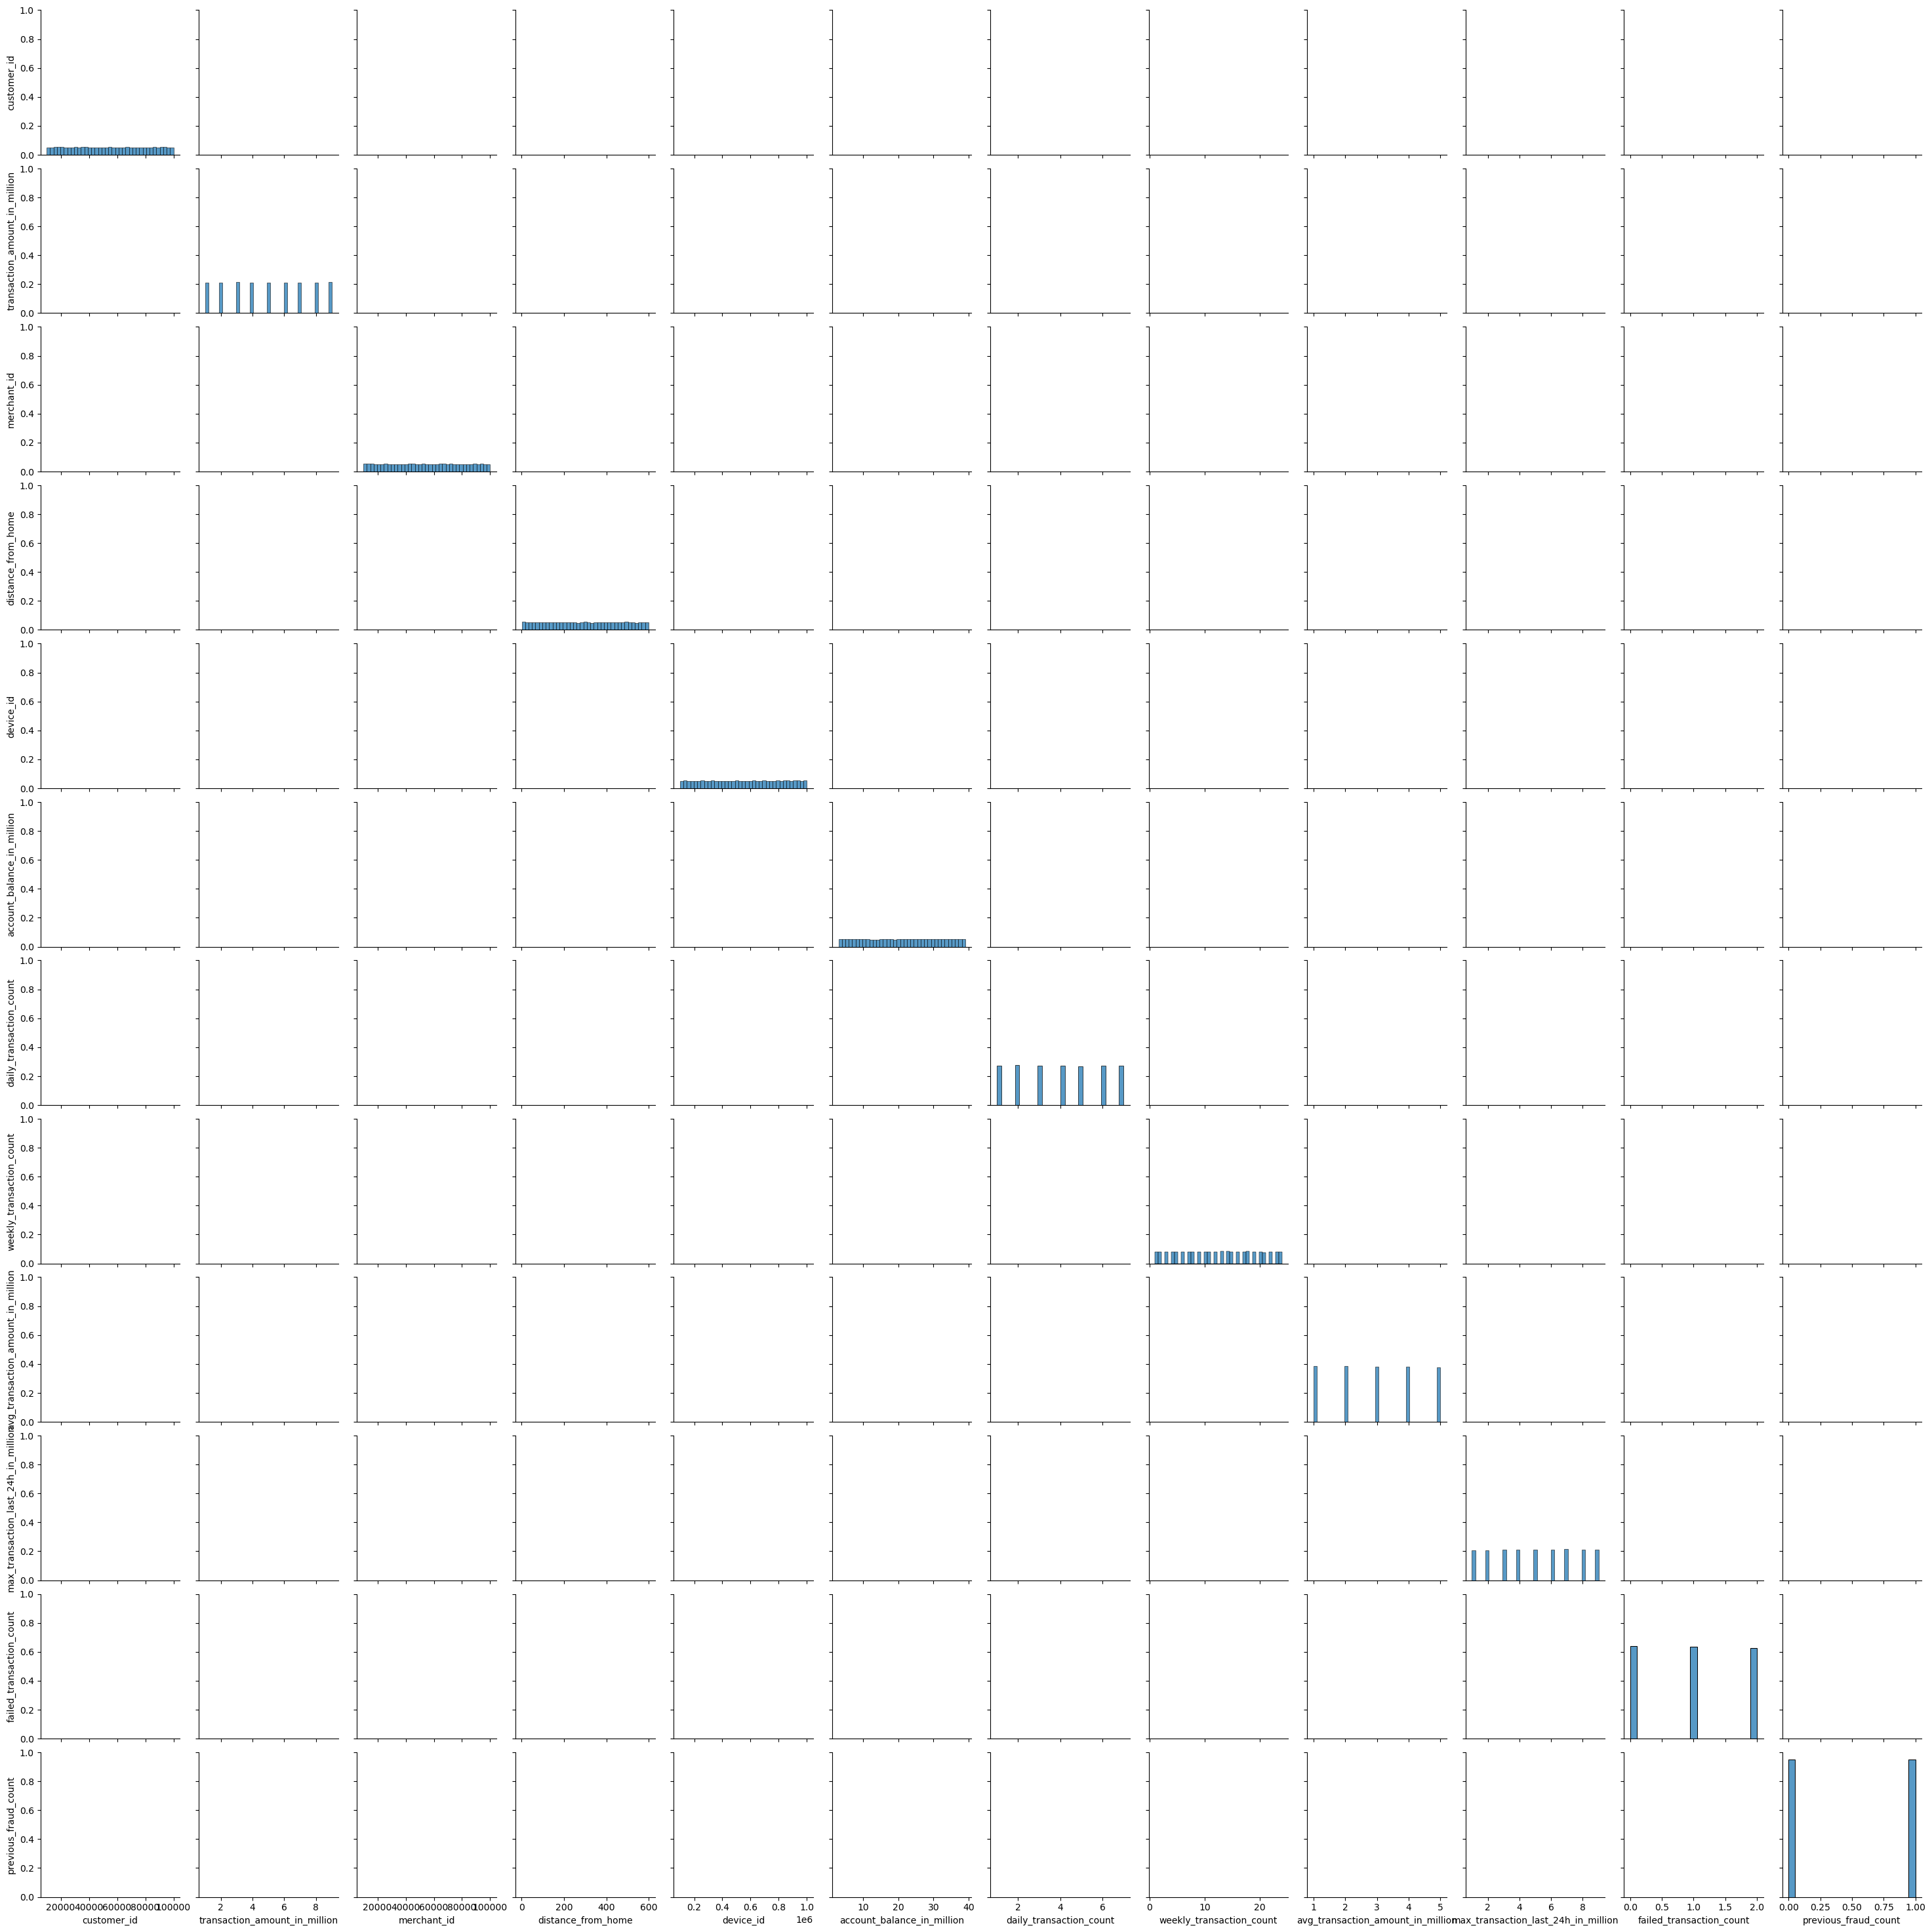

In [88]:
sns.pairplot(df, kind="fraud_abel")

plt.savefig("../4_Datshboards_\_Visualisations/pairplot.png",
            bbox_inches="tight")
plt.show()


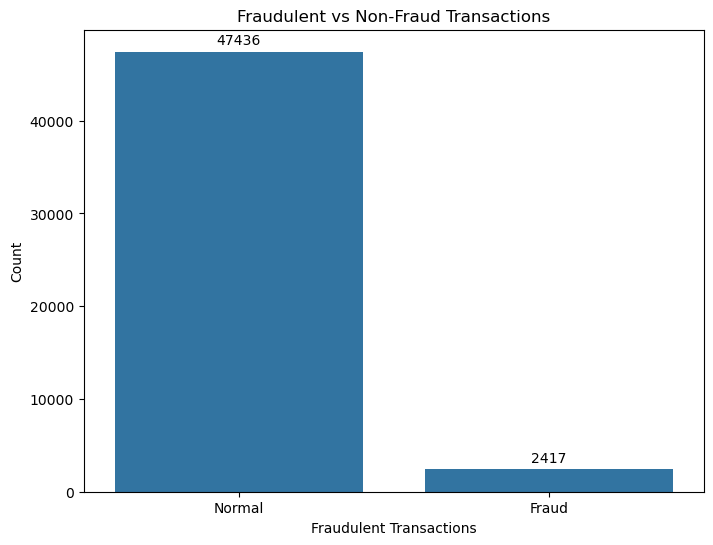

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
ax = sns.countplot(x="fraud_label", data=df)

ax.set_title("Fraudulent vs Non-Fraud Transactions")
ax.set_xlabel("Fraudulent Transactions")
ax.set_ylabel("Count")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.savefig("../../Project_banking-fraud-analytics-dashboard-ml-risk/4_ Datshboards_\_Visualisations/distribution_of_fadulent_Transaction.png", bbox_inches="tight")
plt.show()


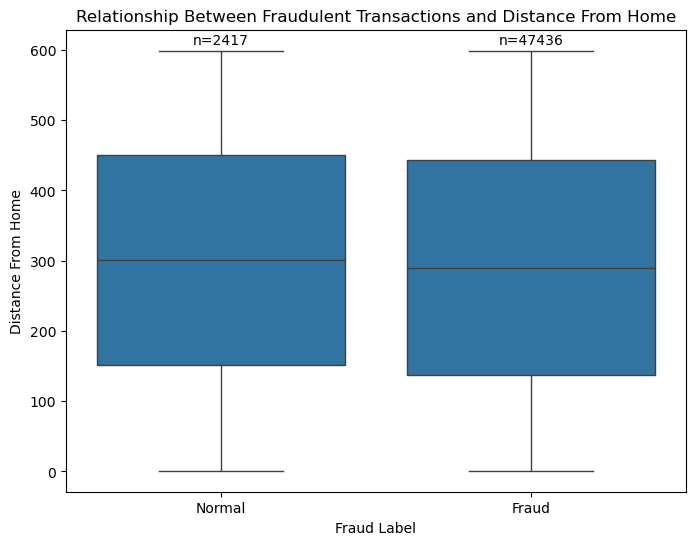

In [62]:
#distance from home


# Compute counts per fraud_label
counts = df["fraud_label"].value_counts().sort_index()

plt.figure(figsize=(8,6))
ax = sns.boxplot(x="fraud_label", y="distance_from_home", data=df)

ax.set_title("Relationship Between Fraudulent Transactions and Distance From Home")
ax.set_xlabel("Fraud Label")
ax.set_ylabel("Distance From Home")

# Add counts on top of each box
for i, label in enumerate(counts.index):
    # y position just above the whisker (you can tweak this)
    y_pos = df[df["fraud_label"] == label]["distance_from_home"].max() + 5
    ax.text(i, y_pos, f"n={counts[label]}", ha="center", va="bottom", fontsize=10)

plt.savefig("../../Project_banking-fraud-analytics-dashboard-ml-risk/4_Datshboards_\_Visualisations/fradulent_transaction_distance_home.png",
            bbox_inches="tight")
plt.show()

# there is no real difference between 

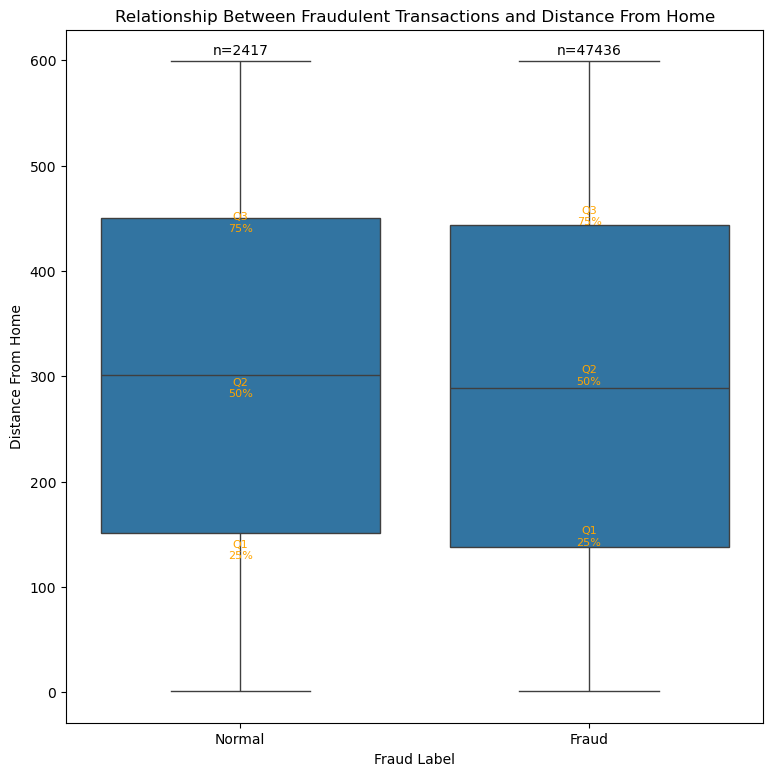

In [81]:


# Compute counts per fraud_label
counts = df["fraud_label"].value_counts().sort_index()

plt.figure(figsize=(9,9))
ax = sns.boxplot(x="fraud_label", y="distance_from_home", data=df)

ax.set_title("Relationship Between Fraudulent Transactions and Distance From Home")
ax.set_xlabel("Fraud Label")
ax.set_ylabel("Distance From Home")

# Add counts and percentiles for each fraud_label
for i, label in enumerate(counts.index):
    # Subset
    subset = df[df["fraud_label"] == label]["distance_from_home"].dropna()
    
    # Quantiles: 25th, 50th, 75th
    q25, q50, q75 = subset.quantile([0.25, 0.50, 0.75])
    
    # Position above the box
    y_count = df[df["fraud_label"] == label]["distance_from_home"].max() + 4
    y_q25   = q25 - 3
    y_q50   = q50
    y_q75   = q75 + 2

    # Count label
    ax.text(i, y_count, f"n={counts[label]}", ha="center", va="bottom", fontsize=10, color="black")

    
    # Percentile labels
    ax.text(i, y_q25, "Q1\n25%", ha="center", va="center", fontsize=8, color="orange")
    ax.text(i, y_q50, "Q2\n50%", ha="center", va="center", fontsize=8, color="orange")
    ax.text(i, y_q75, "Q3\n75%", ha="center", va="center", fontsize=8, color="orange")


plt.savefig("../4_Datshboards_\_Visualisations/fradulent_transaction_distance_home_2.png",
            bbox_inches="tight")
plt.show()


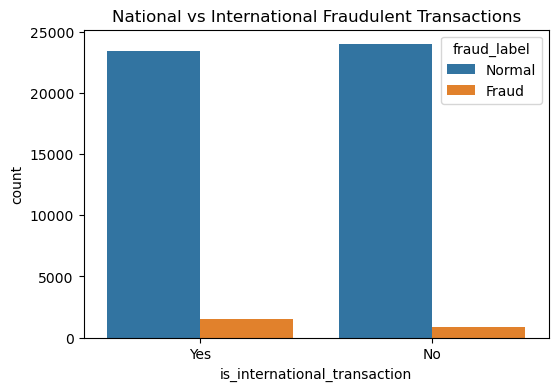

In [84]:
plt.figure(figsize=(6,4))
sns.countplot(x="is_international_transaction", hue="fraud_label", data=df)
plt.title("National vs International Fraudulent Transactions")

plt.savefig("../4_Datshboards_\_Visualisations/fradulent_international_transaction.png",
            bbox_inches="tight")
plt.show()

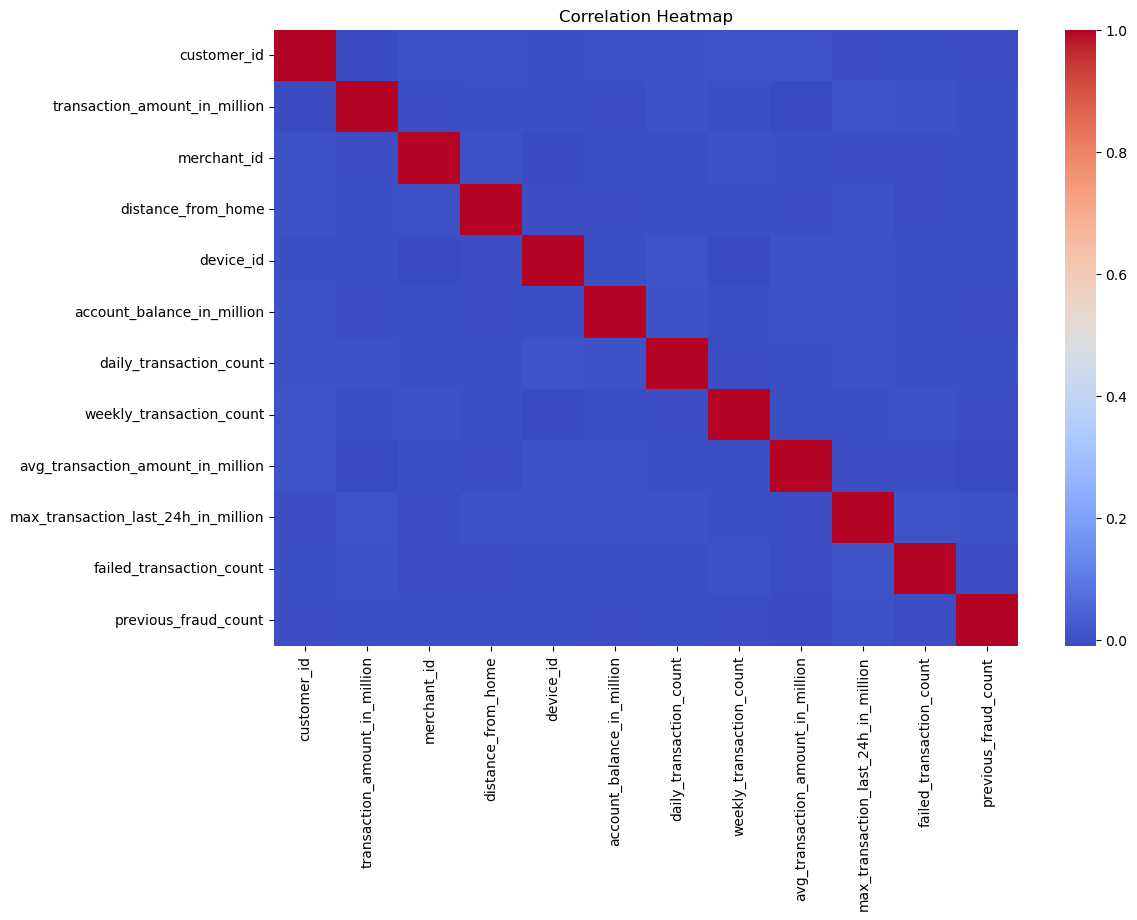

In [87]:

numeric_df = df.select_dtypes(include="number")
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")

plt.savefig("../4_Datshboards_\_Visualisations/correlation_heatmap.png",
            bbox_inches="tight")
plt.show()